# Rede Neural para o Problema XOR com PyTorch


## Importações


In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

## Hiperparâmetros (Implementação do problema do XOR)


In [43]:
LEARNING_RATE = 0.001
EPOCHS = 10000
BATCH_SIZE = 1 # 1 = SGD, 2 = Mini-Batch, 4 = Batch Gradient Descent
HIDDEN_LAYERS = 1
NEURONS = 3
ACTIVATION = "relu" # relu | sigmoid | tanh
OPTIMIZER = "SGD" # SGD | Adam
MOMENTUM = 0.8
WEIGHT_DECAY = 0.0001
DROPOUT = 0
EARLY_STOPPING = True
PATIENCE = 100

## BASE XOR


In [44]:
X = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
])

y = torch.tensor([
    [0.],
    [1.],
    [1.],
    [0.]
])

## Criando o Dataset e DataLoader


In [45]:
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

## ESCOLHA DA FUNÇÃO DE ATIVAÇÃO


In [46]:
if ACTIVATION.lower() == "relu":
    activation = nn.ReLU()
elif ACTIVATION.lower() == "sigmoid":
    activation = nn.Sigmoid()
elif ACTIVATION.lower() == "tanh":
    activation = nn.Tanh()
else:
    raise ValueError("Função de ativação inválida.")

## CONSTRUÇÃO DA REDE NEURAL (MLP) - Primeiras Camadas


In [47]:
layers = []

## Primeira camada


In [48]:
layers.append(nn.Linear(2, NEURONS))
layers.append(activation)

## Dropout (opcional)


In [49]:
if DROPOUT > 0:
    layers.append(nn.Dropout(DROPOUT))

## Camadas ocultas adicionais


In [50]:
for _ in range(HIDDEN_LAYERS - 1):
    layers.append(nn.Linear(NEURONS, NEURONS))
    layers.append(activation)
    if DROPOUT > 0:
        layers.append(nn.Dropout(DROPOUT))

## Camada de saída


In [51]:
layers.append(nn.Linear(NEURONS, 1))
layers.append(nn.Sigmoid())

## Cria a rede neural


In [52]:
model = nn.Sequential(*layers)

## Mostra a arquitetura da rede


In [53]:
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=3, bias=True)
  (1): ReLU()
  (2): Linear(in_features=3, out_features=1, bias=True)
  (3): Sigmoid()
)


## FUNÇÃO DE PERDA


In [54]:
criterion = nn.MSELoss()

## OTIMIZADOR


In [55]:
if OPTIMIZER.upper() == "SGD":
    optimizer = optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )
elif OPTIMIZER.upper() == "ADAM":
    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
else:
    raise ValueError("Otimizador inválido.")

## VARIÁVEIS DE CONTROLE DO TREINAMENTO


In [56]:
loss_history = []
best_loss = float("inf")
counter = 0

print("Iniciando treinamento...")

Iniciando treinamento...


## Loop principal de treinamento


In [57]:
for epoch in range(EPOCHS):
    # Coloca a rede em modo de treinamento
    model.train()

    # Soma da Loss da época
    epoch_loss = 0

    # Percorre todos os batches do DataLoader
    for batch_x, batch_y in loader:
        # 1) Zera os gradientes calculados anteriormente
        optimizer.zero_grad()

        # 2) Forward Pass: Calcula a saída da rede neural
        prediction = model(batch_x)

        # 3) Calcula a função de perda (Loss)
        loss = criterion(prediction, batch_y)

        # 4) Backpropagation: Calcula automaticamente todos os gradientes
        loss.backward()

        # 5) Atualização dos pesos
        optimizer.step()

        # Soma a Loss do batch atual
        epoch_loss += loss.item()

    # Calcula a Loss média da época
    epoch_loss /= len(loader)

    # Armazena para construção do gráfico
    loss_history.append(epoch_loss)

    # Mostra a evolução do treinamento
    if (epoch + 1) % 500 == 0:
        print(f"Época: {epoch+1:5d} | Loss = {epoch_loss:.6f}\n")

    # EARLY STOPPING
    if EARLY_STOPPING:
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            counter = 0
        else:
            counter += 1

        if counter >= PATIENCE:
            print("Early Stopping ativado.")
            print(f"Treinamento encerrado na época {epoch+1}.")
            break

Época:   500 | Loss = 0.234601

Época:  1000 | Loss = 0.222381

Época:  1500 | Loss = 0.207424

Época:  2000 | Loss = 0.192819

Época:  2500 | Loss = 0.180571

Época:  3000 | Loss = 0.169731

Época:  3500 | Loss = 0.156006

Época:  4000 | Loss = 0.134320

Época:  4500 | Loss = 0.103163

Época:  5000 | Loss = 0.070202

Época:  5500 | Loss = 0.048142

Época:  6000 | Loss = 0.034989

Época:  6500 | Loss = 0.026804

Época:  7000 | Loss = 0.021383

Época:  7500 | Loss = 0.017590

Época:  8000 | Loss = 0.014808

Época:  8500 | Loss = 0.012709

Época:  9000 | Loss = 0.011084

Época:  9500 | Loss = 0.009799

Época: 10000 | Loss = 0.008755



## TESTE DA REDE


### Coloca a rede em modo de avaliação


In [58]:
print("\nRESULTADOS")
model.eval()


RESULTADOS


Sequential(
  (0): Linear(in_features=2, out_features=3, bias=True)
  (1): ReLU()
  (2): Linear(in_features=3, out_features=1, bias=True)
  (3): Sigmoid()
)

## Desabilita o cálculo de gradientes


In [59]:
# Desabilita o cálculo de gradientes
with torch.no_grad():
    output = model(X)

print("\nEntrada -> Saída Esperada | Saída Predita")
for entrada, esperado, previsto in zip(X, y, output):
    if previsto.item() >= 0.5:
        classe = 1
    else:
        classe = 0
    print(f"{entrada.numpy()} -> {int(esperado.item())} | {previsto.item():.4f} ({classe})")


Entrada -> Saída Esperada | Saída Predita
[0. 0.] -> 0 | 0.0703 (0)
[0. 1.] -> 1 | 0.8891 (1)
[1. 0.] -> 1 | 0.8891 (1)
[1. 1.] -> 0 | 0.0740 (0)


## GRÁFICO DA CURVA DE APRENDIZADO

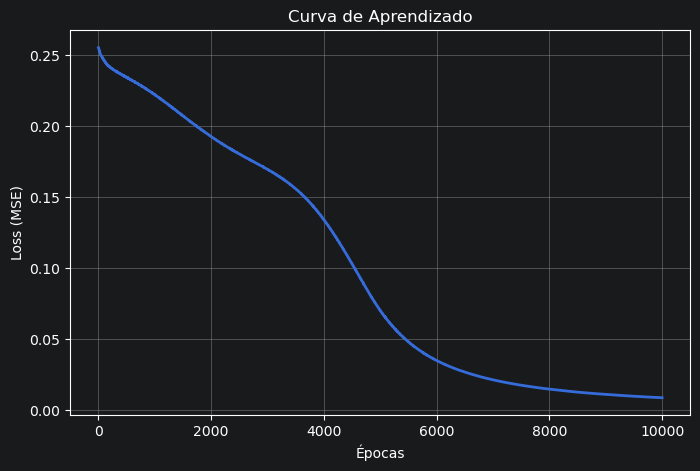

In [60]:

plt.figure(figsize=(8, 5))
plt.plot(loss_history, linewidth=2)
plt.title("Curva de Aprendizado")
plt.xlabel("Épocas")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()